In [1]:
# Notebook 4:
# Sentence-BERT (SBERT) Embeddings and Inference

In [18]:
# !pip install sentence-transformers

In [3]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

import numpy as np
import pandas as pd

d:\Books\projects-nlp-transformers-learning\.projectnlps\Lib\site-packages\sentence_transformers\cross_encoder\CrossEncoder.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


In [4]:
model_name = "sentence-transformers/all-MiniLM-L6-v2"

model = SentenceTransformer(model_name)

print("SBERT Model Loaded!")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

d:\Books\projects-nlp-transformers-learning\.projectnlps\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\vinna\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

'(ProtocolError('Connection aborted.', ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None)), '(Request ID: f6bbee43-3f91-4dd2-93e6-9d6cd0b1a724)')' thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/1110a243fdf4706b3f48f1d95db1a4f5529b4d41/1_Pooling/config.json
Retrying in 1s [Retry 1/5].
'(ProtocolError('Connection aborted.', ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None)), '(Request ID: 0efbbd1c-294b-4bee-aa1c-ec38aa23fe3e)')' thrown while requesting HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/1110a243fdf4706b3f48f1d95db1a4f5529b4d41/1_Pooling%2Fconfig.json
Retrying in 1s [Retry 1/5].


config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

SBERT Model Loaded!


In [5]:
sentence = "I love learning Artificial Intelligence."

embedding = model.encode(sentence)

print("Embedding Shape:")
print(embedding.shape)

Embedding Shape:
(384,)


In [6]:
print(embedding[:20])

[ 0.0183605  -0.08671132  0.06288255  0.01126731  0.04105666 -0.05832995
  0.02440277  0.02937803  0.06191138  0.05505046 -0.02571642  0.0394774
 -0.01427606  0.06041127 -0.00698709  0.00681761 -0.05039332  0.00513337
 -0.07840192 -0.10545732]


In [7]:
sentence1 = "The dog chased the cat."
sentence2 = "A hound pursued the feline."

embeddings = model.encode([sentence1, sentence2])

print(embeddings.shape)

(2, 384)


In [8]:
similarity = cosine_similarity([embeddings[0]], [embeddings[1]])

print("SBERT Similarity:", round(similarity[0][0], 3))

SBERT Similarity: 0.559


In [9]:
sentences = [
    "I love machine learning.",
    "I enjoy studying AI.",
    "Deep learning is fascinating.",
    "Pizza tastes delicious.",
    "Traveling is fun.",
]

embeddings = model.encode(sentences)

print(embeddings.shape)

(5, 384)


In [10]:
similarity_matrix = cosine_similarity(embeddings)

similarity_df = pd.DataFrame(
    similarity_matrix,
    columns=[f"S{i+1}" for i in range(len(sentences))],
    index=[f"S{i+1}" for i in range(len(sentences))],
)

similarity_df.round(2)

,S1,S2,S3,S4,S5
S1,1.00,0.55,0.68,0.20,0.22
S2,0.55,1.00,0.46,0.08,0.33
S3,0.68,0.46,1.00,0.09,0.28
S4,0.20,0.08,0.09,1.00,0.18
S5,0.22,0.33,0.28,0.18,1.00


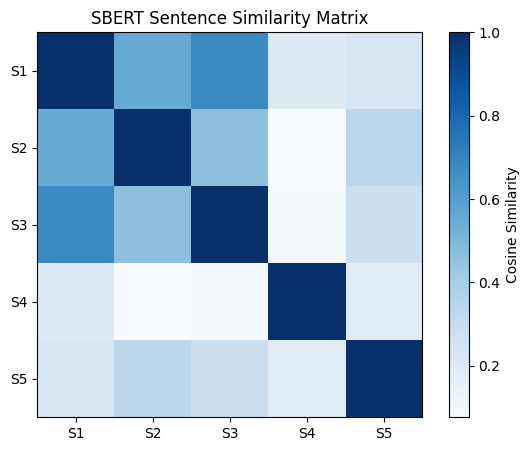

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.imshow(similarity_matrix, cmap="Blues")

plt.colorbar(label="Cosine Similarity")

plt.xticks(range(len(sentences)), [f"S{i+1}" for i in range(len(sentences))])

plt.yticks(range(len(sentences)), [f"S{i+1}" for i in range(len(sentences))])

plt.title("SBERT Sentence Similarity Matrix")

plt.show()

In [12]:
documents = [
    "Learn Python programming from scratch.",
    "Beginner guide to Artificial Intelligence.",
    "Introduction to Machine Learning.",
    "Top travel destinations in Europe.",
    "Best homemade pizza recipes.",
]

doc_embeddings = model.encode(documents)

print("Document Embeddings Shape:")

print(doc_embeddings.shape)

Document Embeddings Shape:
(5, 384)


In [13]:
query = "How can I start learning AI?"

query_embedding = model.encode(query)

In [14]:
scores = cosine_similarity([query_embedding], doc_embeddings)[0]

results = pd.DataFrame({"Document": documents, "Similarity": scores})

results = results.sort_values(by="Similarity", ascending=False)

results

,Document,Similarity
1,Beginner guide to Artificial Intelligence.,0.744769
0,Learn Python programming from scratch.,0.430910
2,Introduction to Machine Learning.,0.298245
4,Best homemade pizza recipes.,0.115026
3,Top travel destinations in Europe.,0.019992


In [15]:
def semantic_search(query, corpus, model, top_k=3):

    corpus_embeddings = model.encode(corpus)

    query_embedding = model.encode(query)

    scores = cosine_similarity([query_embedding], corpus_embeddings)[0]

    result_df = pd.DataFrame({"Document": corpus, "Similarity": scores})

    result_df = result_df.sort_values(by="Similarity", ascending=False)

    return result_df.head(top_k)

In [16]:
semantic_search(query="How do I study AI?", corpus=documents, model=model, top_k=3)

,Document,Similarity
1,Beginner guide to Artificial Intelligence.,0.679604
0,Learn Python programming from scratch.,0.328768
2,Introduction to Machine Learning.,0.240420
